# Salary Prediction Practice (Linear Regression)

Notebook ini dibuat untuk latihan memprediksi gaji berdasarkan masa kerja menggunakan **Linear Regression**.

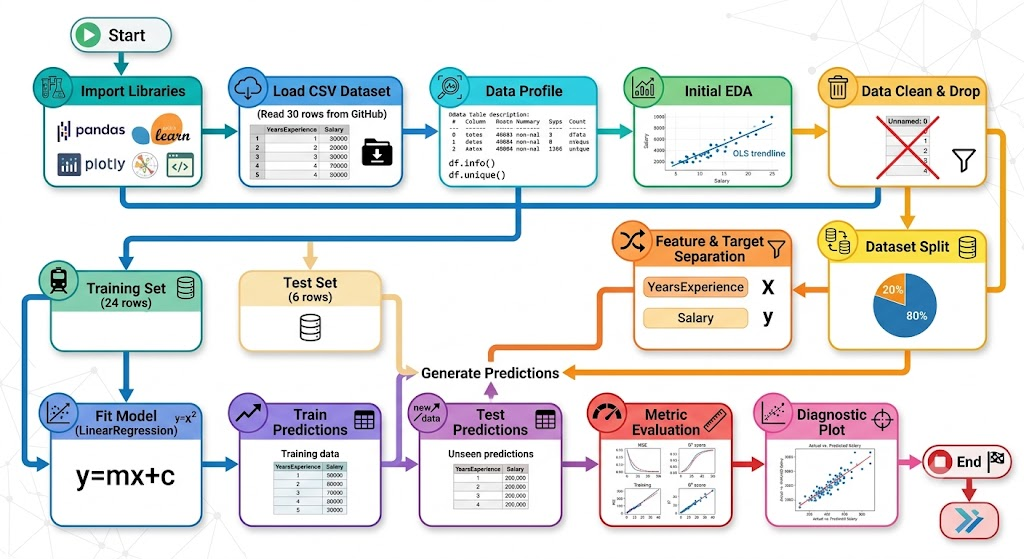


## 1. Import Library


In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as ex
import plotly.graph_objects as gb
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [46]:
df = pd.read_csv("https://raw.githubusercontent.com/mpfordreamer/regression-practice/main/dataset/Salary-dataset.csv")
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


### A. Struktur Data


In [47]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


### B. Cek Nilai Unik


In [48]:
df.nunique()


,0
Unnamed: 0,30
YearsExperience,28
Salary,30


## 2. Visualisasi Data


In [49]:
fig=ex.scatter(data_frame=df,x="YearsExperience",y="Salary",size="YearsExperience",trendline='ols')
fig.show()

## 3. Preprocessing Data


### A. Pemisahan Fitur & Target


In [50]:
df.drop('Unnamed: 0', axis=1, inplace=True)

In [51]:
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

### B. Split Dataset


In [52]:
(X_train, X_test, y_train, y_test) = train_test_split(X, y, test_size=0.2, random_state=42)

## 4. Pembangunan Model


In [53]:
lr=LinearRegression().fit(X_train,y_train)
lr

LinearRegression()

## 5. Membuat Prediksi


In [54]:
y_train_pred = lr.predict(X_train)
y_test_pred = lr.predict(X_test)


## 6. Evaluasi Metrik


In [55]:
train_rme=mean_squared_error(y_train,y_train_pred)
test_rme=mean_squared_error(y_test,y_test_pred)
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)
print(f"train_rme: {train_rme}\n"
      f"test_rme: {test_rme}\n"
      f"train_r2: {train_r2}\n"
      f"test_r2: {test_r2}")

train_rme: 27102249.73126133
test_rme: 49830096.855908394
train_r2: 0.9645401573418148
test_r2: 0.9024461774180497


### A. Komparasi Data


In [56]:
train_data = pd.DataFrame({'Actual': y_train.ravel(), 'Predicted': y_train_pred.ravel(), 'Dataset': 'Training'})
test_data = pd.DataFrame({'Actual': y_test.ravel(), 'Predicted': y_test_pred.ravel(), 'Dataset': 'Testing'})

# Concatenate both DataFrames
combined_data = pd.concat([train_data, test_data], ignore_index=True)

/tmp/ipykernel_4966/1761490315.py:1: FutureWarning:

Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.

/tmp/ipykernel_4966/1761490315.py:2: FutureWarning:

Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.



### B. Plot Hasil Prediksi


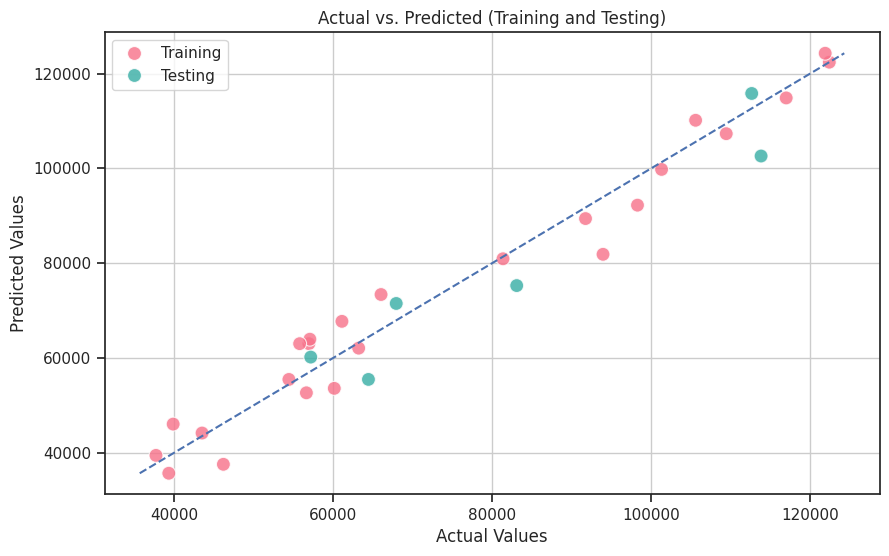

In [57]:
sns.set(style='ticks')
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual', y='Predicted', hue='Dataset', data=combined_data, s=100, alpha=0.8, palette='husl')

plt.plot(
    [min(y.min(), y_train_pred.min()) - 1, max(y.max(), y_train_pred.max()) + 1],
    [min(y.min(), y_train_pred.min()) - 1, max(y.max(), y_train_pred.max()) + 1],
    'b--'
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted (Training and Testing)')

plt.legend()
plt.grid(True)
plt.show()


###Linear Regression (Baseline)

In [58]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

mse_lr = mean_squared_error(y_test, y_pred_lr)

print("MSE Linear Regression :", mse_lr)

MSE Linear Regression : 49830096.855908394


###Random Forest Regression

In [59]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)

print("MSE Random Forest :", mse_rf)

MSE Random Forest : 59083381.47814042


###Gradient Boosting Regression

In [60]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

mse_gbr = mean_squared_error(y_test, y_pred_gbr)

print("MSE Gradient Boosting :", mse_gbr)

MSE Gradient Boosting : 98678750.07301438


###XGBoost

In [61]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)

print("MSE XGBoost :", mse_xgb)

MSE XGBoost : 101159816.08314006


###Bandingkan Semua MSE

               Model           MSE
0  Linear Regression  4.983010e+07
1      Random Forest  5.908338e+07
2  Gradient Boosting  9.867875e+07


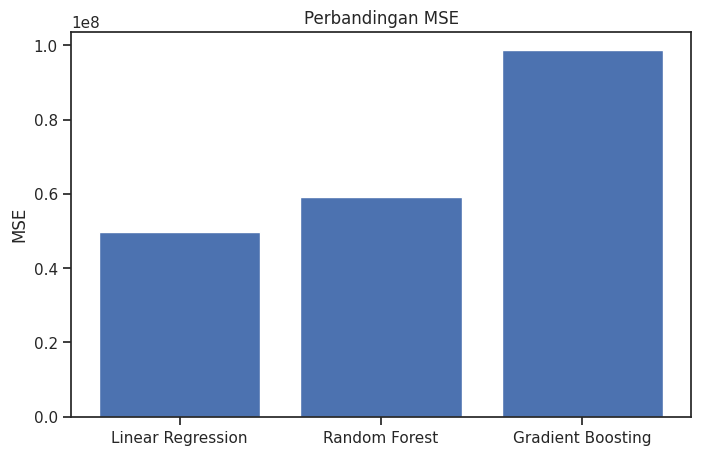

In [62]:
hasil = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MSE': [
        mse_lr,
        mse_rf,
        mse_gbr
    ]
})

print(hasil.sort_values('MSE'))

plt.figure(figsize=(8,5))

plt.bar(
    hasil['Model'],
    hasil['MSE']
)

plt.title("Perbandingan MSE")
plt.ylabel("MSE")
plt.show()

###Visualisasi Prediksi vs Aktual

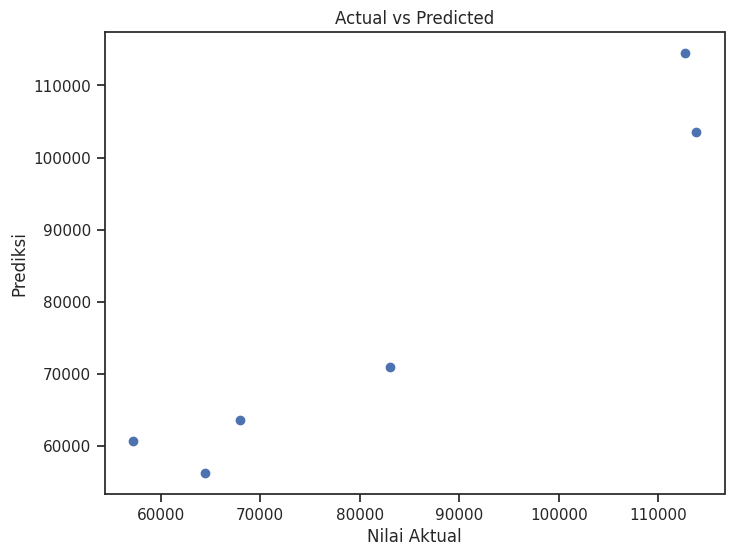

In [63]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Nilai Aktual")
plt.ylabel("Prediksi")

plt.title("Actual vs Predicted")

plt.show()

###Simpan Dataset ke CSV

In [64]:
df.to_csv(
    'dataset_baru.csv',
    index=False
)